# Práctica 1 - Aprendizaje Automático
# EDA y modelado: analizamos la estructura del conjunto de datos 
Analizaremos: tamaño del conjunto de datos, las columnas que tiene, el tipo de datos, variables categóricas y numéricas, la cardinalidad de las categóricas y si esta es alta, si existen variables con valores faltantes y en qué proporción, si existen columnas con valores constantes o identificadores y si existe un problema de balanceo para la variable objetivo.

In [8]:
import pandas as pd
import numpy as np

In [9]:
SEED = 100499078
TARGET = "deposit"

In [10]:
#ruta=r"C:\Users\saram\OneDrive\Documentos\Universidad\Cuarto\Segundo cuatri\Aprendizaje Automático\Práctica 1 - AA\ALL_bank\bank_78.pkl"
ruta=r"C:\Users\claug\OneDrive\Escritorio\Uni\4 de carrera\aprendizaje automático\Practica1AA\bank_ALL\bank_78.pkl"

In [11]:
df = pd.read_pickle(ruta)

In [12]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## Tamaño del conjunto de datos

In [13]:
print("Tamaño", df.shape) 
# 1100 filas x 17 columnas

Tamaño (11000, 17)


## Columnas

In [14]:
print("\nColumnas:")
print(df.columns.tolist())


Columnas:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


## Tipo de dato de las columnas

In [15]:
print("\nTipos de datos:")
display(df.dtypes.to_frame("dtype"))


Tipos de datos:


,dtype
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


## Diferenciamos variables categóricas y numéricas (variables X)

In [16]:
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Variable objetivo --> la quitamos
if TARGET in categorical_cols:
    categorical_cols.remove(TARGET)
if TARGET in numeric_cols:
    numeric_cols.remove(TARGET)
    
print("\nCategóricas:", categorical_cols)
print("\nNuméricas:", numeric_cols)


Categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Numéricas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


## Cardinalidad de categorías

In [17]:
# Cuántos valores distintos tiene cada variable categórica

cardinality = pd.DataFrame({"n_unique": df[categorical_cols].nunique(dropna=False)}).sort_values("n_unique", ascending=False)
cardinality["alta_cardinalidad_>10"] = cardinality["n_unique"] > 10
display(cardinality)

,n_unique,alta_cardinalidad_>10
job,13,True
month,12,True
marital,4,False
poutcome,4,False
education,4,False
contact,3,False
default,2,False
housing,2,False
loan,2,False


La mayoría de variables no superan los 10 valores distintos. No obstante, "job" y "month" sí, lo que implica que tendremos que tenerlas en cuenta en el preprocesado de datos. Por ejemplo, si luego hacemos one-hot encoding una variable con 13 valores genera muchas más columnas que una con 4. 


## Variables con valores faltantes

In [18]:
missing = pd.DataFrame({"n_missing": df.isna().sum(), "pct_missing": df.isna().mean() * 100}).sort_values("n_missing", ascending=False)
display(missing[missing["n_missing"]>10])

,n_missing,pct_missing
marital,295,2.681818
job,123,1.118182


Vemos valores faltantes en "marital" y "job"; sin embargo, el porcentaje es relativamente bajo. Aun así, esto lo trataremos en el preprocesado quizá mediante una estrategia de imputación dentro del pipeline. 

## Columnas con valores constantes e ID

In [19]:
constant_cols = [col for col in df.columns if df[col].nunique(dropna=False) == 1]

print("Número de columnas constantes:", len(constant_cols))
print("Columnas constantes:", constant_cols)

Número de columnas constantes: 0
Columnas constantes: []


In [20]:
# Buscaremos columnas donde el número de valores únicos sea igual al número de filas

possible_id_cols = [col for col in df.columns if df[col].nunique(dropna=False) == len(df)]
print("\nNúmero de posible columnas ID:", len(possible_id_cols))
print("\nPosible columnas ID:", possible_id_cols)


Número de posible columnas ID: 0

Posible columnas ID: []


No hay columnas constantes ni variables que parezcan ser identificadores únicos. Por tanto, no parece haber columnas triviales o de identificación directa que tengamos que eliminar por este motivo.

## Variable objetivo

In [21]:
print(df[TARGET].value_counts())
print("\nPorcentajes:")
print((df[TARGET].value_counts(normalize=True) * 100).round(2))

deposit
no     5780
yes    5220
Name: count, dtype: int64

Porcentajes:
deposit
no     52.55
yes    47.45
Name: proportion, dtype: float64


## ¿Existe problema de desbalanceo?
La variable objetivo presenta una distribución relativamente equilibrada entre clases (52.55 vs 47.75), por lo que **no parece existir un problema importante de desbalanceo.**

## Análisis particular de `pdays`
La variable `pdays` requiere un análisis específico dentro del EDA, ya que el valor `-1` no representa una cantidad real de días, sino que indica que el cliente no había sido contactado previamente o que no se conoce dicha información. Por tanto, no es adecuado tratar este valor como si fuese un valor numérico normal.

Con el fin de representar mejor la información de esta variable, planteamos una transformación en dos pasos:
1. Construiremos una variable binaria que indique si el cliente había sido contactado previamente o no.
2. Generaremos una versión discretizada de `pdays`, agrupando los valores positivos en intervalos, para así simplificar su interpretación y facilitar su uso posterior en el modelado.

count    11000.000000
mean        51.308636
std        108.782842
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         20.250000
max        854.000000
Name: pdays, dtype: float64

Frecuencia de pdays = -1:
8203

Porcentaje de pdays = -1:
74.57 %


<Axes: ylabel='Frequency'>

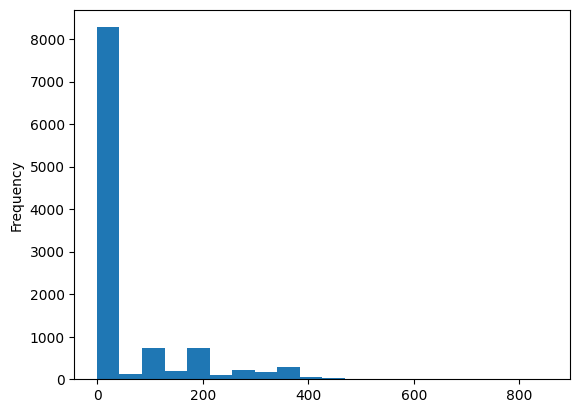

In [22]:
# Distribución inicial de pdays
print(df["pdays"].describe())

print("\nFrecuencia de pdays = -1:")
print((df["pdays"] == -1).sum())

print("\nPorcentaje de pdays = -1:")
print(round((df["pdays"] == -1).mean() * 100, 2), "%")

df['pdays'].plot.hist(bins=20)

La variable `pdays` presenta una distribución muy particular, ya que el valor `-1` aparece en 8203 observaciones, lo que supone un 74.57% del total. Además, tanto el primer cuartil como la mediana toman el valor `-1`, lo que confirma que este código domina la distribución. Esto nos indica que `pdays` no debe tratarse como una variable numérica ordinaria, sino como una variable con un valor especial que representa que no ha habido contacto previo o valor desconocido. 
Por ello, resulta razonable transformarla en variables más interpretables, como una variable binaria de contacto previo y una versión discretizada por intervalos.

In [23]:
# Variable binaria: indica si hubo o no contacto previo

def play_transforms(x):
    if x == -1:
        return 0
    else:
        return 1
        
df['wascontacted'] = df['pdays'].map(play_transforms)

In [24]:
# Variable agrupada a partir de pdays

def bin_pdays(x):
    if x == -1:
        return "no_contacto"
    elif x < 100:
        return "0_99"
    elif x < 200:
        return "100_199"
    elif x < 400:
        return "200_399"
    else:
        return "400_plus"

df["pdays_binned"] = df["pdays"].map(bin_pdays)

# Mostramos un ejemplo de varios grupos para ver que la agrupación la hemos hecho bien

display(df[["pdays", "wascontacted", "pdays_binned"]].head())
display(df.loc[(df["pdays"] >= 0) & (df["pdays"] < 100), ["pdays", "wascontacted", "pdays_binned"]].head())
display(df.loc[(df["pdays"] >= 100) & (df["pdays"] < 200), ["pdays", "wascontacted", "pdays_binned"]].head())

display(df["pdays_binned"].value_counts(dropna=False))

,pdays,wascontacted,pdays_binned
0,-1,0,no_contacto
1,-1,0,no_contacto
2,-1,0,no_contacto
3,-1,0,no_contacto
4,-1,0,no_contacto


,pdays,wascontacted,pdays_binned
891,91,1,0_99
994,27,1,0_99
1039,34,1,0_99
1043,10,1,0_99
1062,99,1,0_99


,pdays,wascontacted,pdays_binned
890,166,1,100_199
899,147,1,100_199
933,170,1,100_199
951,150,1,100_199
952,171,1,100_199


pdays_binned
no_contacto    8203
100_199        1058
200_399         871
0_99            735
400_plus        133
Name: count, dtype: int64

A parte de las conclusiones que habíamos mencionado antes observamos que, entre los clientes contactados previamente, la distribución por intervalos muestra que los rangos `100_199` y `200_399` son los más frecuentes, mientras que `400_plus` aparece en un número mucho más reducido de casos. Así, esta es una categoría minoritaria lo que nos podría aportar menos estabilidad en algunos modelos. 

In [25]:
df["contacted_label"].value_counts().plot.bar()

KeyError: 'contacted_label'

### Decisión de preprocesado de `pdays`
Tras el análisis realizado, concluimos que la variable `pdays` no debe tratarse como una variable numérica convencional, ya que el valor `-1` representa ausencia de contacto previo o valor desconocido, y no una cantidad real de días. Por ello, optamos por transformar esta variable en dos nuevas representaciones más informativas: una variable binaria (`wascontacted`) que indica si el cliente había sido contactado previamente, y una variable categórica agrupada (`pdays_binned`) que discretiza los valores positivos en intervalos. 
Luego, en la fase de preparación de datos para el entrenamiento, eliminaremos la variable original `pdays` del conjunto de predictores para evitar interpretaciones erróneas durante el modelado.

# 2. Decisión de evaluación

## 2.1. Evaluación outer tipo Holdout

Como se indica en el enunciado, separaremos el dataset en un conjunto de **train** (2/3) y un conjunto de **test** (1/3), siguiendo una estrategia de evaluación **tipo holdout**. Esta partición se realizará de forma **estratificada** respecto a la variable objetivo, con el fin de mantener aproximadamente la misma proporción de clases en ambas particiones.

De este modo, el **conjunto de test** quedará reservado desde este momento y no se utilizará durante el proceso de análisis, comparación de alternativas, selección de variables ni ajuste de hiperparámetros. Su uso quedará limitado a la evaluación final, una vez se haya decidido la mejor estrategia de modelado.

## 2.2. Métrica de evaluación

Utilizaremos como métrica principal la **accuracy**, ya que, según el análisis previo de la variable objetivo, las clases presentan una distribución relativamente equilibrada.

Recordemos que la **accuracy** mide la proporción de observaciones correctamente clasificadas sobre el total. En este caso, al no existir un desbalanceo fuerte entre clases, esta métrica resulta adecuada para reflejar de forma razonable el desempeño global del modelo.

## 2.3. Evaluación inner

La evaluación interna la realizaremos únicamente sobre el conjunto de entrenamiento mediante **validación cruzada estratificada de 5 particiones**. Esta decisión se justifica porque, durante el desarrollo de la práctica, necesitaremos comparar distintas alternativas utilizando solamente el conjunto de entrenamiento, sin usar el conjunto de test. En este contexto, la validación cruzada nos permite obtener una estimación más robusta y estable del rendimiento que una única partición interna de train.

En concreto, el conjunto de entrenamiento se dividirá en varias particiones y el proceso de entrenamiento-validación se repetirá varias veces, utilizando en cada iteración una partición distinta como validación y las restantes como entrenamiento. De este modo, todas las observaciones del conjunto train participan en la evaluación, lo que reduce la dependencia de una única partición y hace más fiable la comparación entre alternativas.

Además, el hecho de que la validación cruzada sea **estratificada** garantiza que en cada fold se mantenga aproximadamente la misma proporción de clases que en el conjunto de entrenamiento completo. Esto resulta especialmente importante en problemas de clasificación, ya que evita particiones internas poco representativas.

Por último, la elección de **5 folds** responde al equilibrio entre dos aspectos: por un lado, obtener una estimación suficientemente estable del rendimiento y, por otro, no incrementar excesivamente el coste computacional, dado que este procedimiento se aplicará repetidamente al comparar preprocesados, modelos e hiperparámetros.


# 3. Métodos básicos: KNN y Trees

# 3.1. Preparación del conjunto de variables para el modelado
Antes de comparar los métodos KNN y árboles de decisión, es necesario fijar el conjunto de variables que se utilizarán en el modelado y cómo se tratará cada una de ellas en el preprocesado. A partir del análisis, hemos decidido no utilizar la variable `pdays`en su forma orginal. En su lugar, esa información la recogeremos mediante dos variables: `wascontacted`, que indica si el cliente ha sido contactado previamente, y `pdays_binned`, que agrupa en intervalos los casos en los que sí hubo contacto previo. 

In [ ]:



cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'pdays_binned']
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'previous', 'wascontacted']


# 3.2. Selección del método de escalado para KNN
Ahora, antes de evaluar y comparar los métodos considerados en esta sección, es necesario decidir qué **estrategia de escalado** es la más adecuada para KNN. Esto es realmente clave ya que, como el funcionamiento de KNN se basa en distancias, la escala de las variables numéricas puede influir de forma directa en el resultado. En concreto, compararemos los 3 métodos de escalado habituales:
1. `MinMaxScaler`: transforma cada variable para que tome valores dentro de un intervalo fijo.
2. `StandardScaler`: centra y escala las variables en función de su media y desviación típica.
3. `RobustScaler`: utiliza medidas robustas frente a valores extremos, como la mediana y el rango intercuartílico.

Para dicha comparación, se entrenerá un modelo KNN con la misma configuración en los 3 casos, variando únicamente el método de escalado aplicado a las variables numéricas. Utilizaremos la validación cruzada sobre el conjunto de entrenamiento, usando la métrica de accuracy. Así, el escalado con mejor rendimiento medio será el que se utilice a patir de este punto en todos los experimentos con KNN. 

### Separación X e Y

In [ ]:
X = df.drop("deposit", axis=1)
y = df["deposit"]

### Partición de los datos

Para decidir sobre el método de escalado hemos realizado antes una partición holdout del conjunto de datos, separándolo en entrenamiento y test en proporción 2/3–1/3, de forma estratificada respecto a la variable objetivo.

El objetivo de esta partición es disponer de un conjunto de datos independiente que no intervenga en el entrenamiento del modelo, permitiendo así una evaluación final objetiva de su rendimiento.

Como resultado, hemos obtenido:
- Conjunto de entrenamiento: 7333 muestras con 17 variables.
- Conjunto de test: 3667 muestras con 17 variables.

Esta separación garantiza que el modelo se entrena adecuadamente y que su rendimiento puede evaluarse de forma realista sobre datos no vistos previamente.

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=1/3,         
    random_state=SEED, 
    stratify=y             
)

# Evaluación inner: validación cruzada estratificada
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("¡Partición realizada con éxito!")
print(f"Datos para entrenar (X_train): {X_train.shape}")
print(f"Datos ocultos para el test final (X_test): {X_test.shape}")

¡Partición realizada con éxito!
Datos para entrenar (X_train): (7333, 18)
Datos ocultos para el test final (X_test): (3667, 18)


In [ ]:
# Comprobamos que no falta ninguna columna
print("Columnas categóricas:")
print(cat_cols)

print("\nColumnas numéricas:")
print(num_cols)

print("\n¿Falta alguna columna en X_train?")
faltan = [col for col in cat_cols + num_cols if col not in X_train.columns]
print(faltan)

Columnas categóricas:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'pdays_binned']

Columnas numéricas:
['age', 'balance', 'day', 'duration', 'campaign', 'previous', 'wascontacted']

¿Falta alguna columna en X_train?
[]


### Comparación de escaladores

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

scalers = {
    'MinMaxScaler': MinMaxScaler(),
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler()
}

resultados_escalado = []

for nombre_scaler, scaler in scalers.items():
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', scaler, num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
        ]
    )
    
    pipe_knn = Pipeline([
        ('preprocessing', preprocessor),
        ('model', KNeighborsClassifier())
    ])
    
    scores = cross_val_score(
        pipe_knn,
        X_train,
        y_train,
        cv=cv_inner,
        scoring='accuracy',
        n_jobs=-1
    )
    
    resultados_escalado.append({
        'Escalado': nombre_scaler,
        'Accuracy media CV': scores.mean(),
        'Desv. típica CV': scores.std()
    })

df_escalado_knn = pd.DataFrame(resultados_escalado).sort_values(
    by='Accuracy media CV',
    ascending=False
).reset_index(drop=True)

display(df_escalado_knn)

mejor_scalado_nombre = df_escalado_knn.loc[0, 'Escalado']
print(f"El mejor método de escalado para KNN es: {mejor_scalado_nombre}")

NameError: name 'num_cols' is not defined

Los resultados obtenidos nos muestran que StandardScaler tiene la mayor accuracy media en validación cruzada. Además, la desviación típica entre folds es reducida en los 3 casos, lo que nos indica que el comportamiento de los modelos es estable. 
Como consecuencia, seleccionamos **StandardScaler** como método de escalado para KNN en los siguientes experimentos. 

## 3.3. Evaluación con hiperparámetros por omisión
### KNN
Una vez hemos seleccionado el método de escalado más adecuado para KNN, evaluaremos este modelo con sus hiperparámetros por omisión. Para ello, se construye una pipeline completa con el preprocesado de las variables y el clasificador. 
En concreto, las **variables numéricas** se escalan mediante **StandardScaler**, mientras que las **variables categóricas** se transforman mediante **OneHotEncoder**. La evaluación se realizará sobre el conjunto de entrenamiento usando validación cruzada estratificada, y además se medirá el tiempo de entrenamiento.

In [ ]:
# Pipeline de KNN
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import time

preprocessor_knn = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

pipe_knn_default = Pipeline([
    ('preprocessing', preprocessor_knn),
    ('model', KNeighborsClassifier())
])

pipe_knn_default

# Evaluación con validación cruzada
import time
from sklearn.model_selection import cross_val_score

# KNN default
inicio_knn = time.time()
scores_knn_default = cross_val_score(
    pipe_knn_default,
    X_train,
    y_train,
    cv=cv_inner,
    scoring='accuracy',
    n_jobs=-1
)
fin_knn = time.time()
tiempo_knn_default = fin_knn - inicio_knn

print("Accuracy por fold (KNN por defecto):", scores_knn_default)
print(f"Accuracy media CV: {scores_knn_default.mean():.4f}")
print(f"Desviación típica CV: {scores_knn_default.std():.4f}")
print(f"Tiempo de entrenamiento y evaluación CV: {tiempo_knn_default:.4f} segundos")


Accuracy por fold (KNN por defecto): [0.7941377  0.8070893  0.81526926 0.80900409 0.8212824 ]
Accuracy media CV: 0.8094
Desviación típica CV: 0.0091
Tiempo de entrenamiento y evaluación CV: 0.9440 segundos


El modelo obtiene una accuracy media de 0.8094, con una desviación típica de 0.0091 entre folds, lo que indica un **comportamiento bastante estable**. En cuanto al coste computacional, el tiempo total de entrenamiento y evaluación mediante validación cruzada ha sido de 7.705 segundos. Por tanto, KNN con hiperparámetros por defecto es una primera referencia sólida para este problema, que más adelante compararemos con el árbol de decisión y con las versiones ajustadas mediante optimización de hiperparámetros.

### Árbol de decisión
A continuación, evaluaremos un árbol de decisión con sus hiperparámetros por omisión. En este caso, no es necesario aplicar escalado a las variables numéricas, ya que los árboles no se basan en distancias. Sin embargo, las variables categóricas sí deben transformarse mediante codificación para que el modelo pueda utilizarlas.

In [ ]:
# Pipeline de Tree
from sklearn.tree import DecisionTreeClassifier

preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

pipe_tree_default = Pipeline([
    ('preprocessing', preprocessor_tree),
    ('model', DecisionTreeClassifier(random_state=SEED))
])

# Evaluación
inicio_tree = time.time()
scores_tree_default = cross_val_score(
    pipe_tree_default,
    X_train,
    y_train,
    cv=cv_inner,
    scoring='accuracy',
    n_jobs=-1
)
fin_tree = time.time()
tiempo_tree_default = fin_tree - inicio_tree

print("Accuracy por fold (Tree por defecto):", scores_tree_default)
print(f"Accuracy media CV: {scores_tree_default.mean():.4f}")
print(f"Desviación típica CV: {scores_tree_default.std():.4f}")
print(f"Tiempo de entrenamiento y evaluación CV: {tiempo_tree_default:.4f} segundos")

Accuracy por fold (Tree por defecto): [0.78800273 0.799591   0.79277437 0.77830832 0.7851296 ]
Accuracy media CV: 0.7888
Desviación típica CV: 0.0072
Tiempo de entrenamiento y evaluación CV: 0.3852 segundos


### Comparación

In [ ]:
resultados_modelos_default = pd.DataFrame([
    {
        'Modelo': 'KNN (default)',
        'Accuracy media CV': scores_knn_default.mean(),
        'Desv. típica CV': scores_knn_default.std(),
        'Tiempo (s)': tiempo_knn_default
    },
    {
        'Modelo': 'Decision Tree (default)',
        'Accuracy media CV': scores_tree_default.mean(),
        'Desv. típica CV': scores_tree_default.std(),
        'Tiempo (s)': tiempo_tree_default
    }
])

display(resultados_modelos_default.round(4))

,Modelo,Accuracy media CV,Desv. típica CV,Tiempo (s)
0,KNN (default),0.8094,0.0091,0.9440
1,Decision Tree (default),0.7888,0.0072,0.3852


Los resultados muestran que KNN obtiene un mejor rendimiento predictivo, con una accuracy media de 0.8094, frente a 0.7888 del árbol de decisión. Por tanto, en esta primera comparación, KNN se comporta mejor que el árbol. En cuanto al coste computacional, el árbol de decisión resulta más rápido (0.3852 s) que KNN (0.9440 s), aunque ambos tiempos son reducidos. Por ello, puede decirse que KNN ofrece una mejora en rendimiento a cambio de un coste computacional algo mayor, pero todavía moderado. Además, la desviación típica entre folds es baja en ambos modelos, lo que indica que los resultados son estables y consistentes entre particiones.

##Árboles poco profundos
Para comprender cómo el modelo toma sus decisiones basándose en los datos del cliente vamos a entrenar un Árbol de decisión limitando su profundidad máxima a 3 niveles.

In [ ]:
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

print("Entrenando y dibujando árbol poco profundo (max_depth=3)...\n")

# 1. Creamos la pipeline con el árbol limitado
pipe_tree_shallow = Pipeline([
    ('preprocessing', preprocessor_tree),
    ('model', DecisionTreeClassifier(max_depth=3, random_state=SEED))
])

# 2. Entrenamos el modelo directamente (sin validación cruzada, solo para dibujar)
pipe_tree_shallow.fit(X_train, y_train)

# 3. Extraemos los nombres de las columnas que salen del preprocesador
nombres_variables = pipe_tree_shallow.named_steps['preprocessing'].get_feature_names_out()

# 4. Dibujamos el árbol
plt.figure(figsize=(22, 10))
plot_tree(
    pipe_tree_shallow.named_steps['model'],
    feature_names=nombres_variables,
    class_names=['No contrata', 'Sí contrata'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de decisión interpretable (max_depth=3)", fontsize=16)
plt.show()

Entrenando y dibujando árbol poco profundo (max_depth=3)...



NameError: name 'Pipeline' is not defined

#CONCLUSION!!!!!!!!!!!!!!!!

A continuación, vamos a buscar la configuración óptima para nuestros dos modelos.
- Para **KNN**, buscaremos el número óptimo de vecinos.
- Para el **Árbol**, buscaremos la profundidad máxima ideal.

Mediremos los tiempos de este proceso y visualizaremos mediante gráficas cómo afecta la variación de estos parámetros al rendimiento del modelo.

In [26]:
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import pandas as pd
import time

print("Iniciando Búsqueda de Hiperparámetros (HPO)... Esto puede tardar un poco.\n")

param_grid_knn = {'model__n_neighbors': range(1, 31, 2)} # Prueba vecinos impares del 1 al 30

inicio_hpo_knn = time.time()
grid_knn = GridSearchCV(pipe_knn_default, param_grid_knn, cv=cv_inner, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train, y_train)
tiempo_hpo_knn = time.time() - inicio_hpo_knn

param_grid_tree = {'model__max_depth': range(1, 21)} # Prueba profundidades del 1 al 20

inicio_hpo_tree = time.time()
grid_tree = GridSearchCV(pipe_tree_default, param_grid_tree, cv=cv_inner, scoring='accuracy', n_jobs=-1)
grid_tree.fit(X_train, y_train)
tiempo_hpo_tree = time.time() - inicio_hpo_tree

print(f"Mejor KNN encontrado: {grid_knn.best_params_}")
print(f"Accuracy del mejor KNN: {grid_knn.best_score_:.4f} (Tiempo de búsqueda: {tiempo_hpo_knn:.2f} s)\n")

print(f"Mejor Árbol encontrado: {grid_tree.best_params_}")
print(f"Accuracy del mejor Árbol: {grid_tree.best_score_:.4f} (Tiempo de búsqueda: {tiempo_hpo_tree:.2f} s)\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

resultados_knn = pd.DataFrame(grid_knn.cv_results_)
sns.lineplot(data=resultados_knn, x='param_model__n_neighbors', y='mean_test_score', marker='o', ax=axes[0])
axes[0].set_title("Efecto de K vecinos en KNN")
axes[0].set_xlabel("Número de vecinos (n_neighbors)")
axes[0].set_ylabel("Accuracy Media (CV)")

resultados_tree = pd.DataFrame(grid_tree.cv_results_)
sns.lineplot(data=resultados_tree, x='param_model__max_depth', y='mean_test_score', marker='o', color='green', ax=axes[1])
axes[1].set_title("Efecto de la profundidad en Árboles")
axes[1].set_xlabel("Profundidad máxima (max_depth)")
axes[1].set_ylabel("Accuracy Media (CV)")

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'seaborn'

**Análisis de las gráficas:**
- **En KNN:** Observamos que con pocos vecinos el modelo sufre de sobreajuste y generaliza mal. A medida que aumentamos los vecinos, la accuracy sube hasta alcanzar su pico máximo. Si seguimos añadiendo vecinos más allá de ese punto, el modelo se vuelve demasiado rígido y el rendimiento vuelve a caer.
- **En el Árbol de Decisión:** Una profundidad muy baja (underfitting) no es capaz de capturar patrones complejos, dando una accuracy baja. Al aumentar la profundidad, el rendimiento mejora rápidamente hasta llegar al valor óptimo. Si permitimos que el árbol crezca sin control (profundidades mayores a 10-15), comienza a memorizar los datos de entrenamiento (overfitting), provocando que su rendimiento en validación caiga y se vuelva inestable.

##Validamos con distintos modelos
#Regresión logística

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe_lr, X_train, y_train, cv=skf, scoring='accuracy')
print("Accuracy por fold:", scores)
print("Accuracy medio:", scores.mean())

Accuracy por fold: [0.82890252 0.83162918 0.81322427 0.83287858 0.82332879]
Accuracy medio: 0.8259926663077006


#Con un árbol de decisión:

In [ ]:
from sklearn.tree import DecisionTreeClassifier

pipe_tree = Pipeline([
    ('preprocessing', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

#Con random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
pipe_rf = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

In [ ]:
models = {
    "Logistic Regression": pipe_lr,
    "Decision Tree": pipe_tree,
    "Random Forest": pipe_rf
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
    print(f"{name}: {scores.mean():.4f}")

Logistic Regression: 0.8260
Decision Tree: 0.7791
Random Forest: 0.8533


### Selección del modelo

Para la selección del modelo hemos seguido un proceso sistemático que incluye preprocesamiento de los datos, entrenamiento y validación mediante técnicas adecuadas.

Para la evaluación de los modelos hemos utilizado validación cruzada estratificada (`StratifiedKFold`) con 5 particiones, lo que permite mantener la proporción de clases en cada fold y obtener estimaciones robustas del rendimiento.

Hemos evaluado 3 modelos:
- Regresión logística: 0.8260
- Árbol de decisión: 0.7791
- Random Forest: 0.8533
P`KO

??????????????????????????????????????????????
ESTO ES LO QUE, A PARTIR DE AQUÍ, NO SE SI QUITAR:
El modelo seleccionado ha sido **Random Forest**, ya que presenta la mayor accuracy media durante la validación cruzada.

Además, este modelo es capaz de capturar relaciones no lineales y manejar adecuadamente tanto variables numéricas como categóricas, lo que lo hace especialmente adecuado para este problema.